# QPIE Phase 7 — PathMNIST
## Quantum encoding of H&E-stained colon pathology images

PathMNIST: 9-class colon tissue classification (28×28 RGB, ~90K train).  
H&E staining: hematoxylin (blue/purple = nuclei) vs eosin (pink = cytoplasm).  
Tissue types are distinguished primarily by **colour channel ratios** —
exactly what quantum encoding of R/G/B channels should capture.


Train: (89996, 28, 28, 3), Test: (7180, 28, 28, 3)
Classes: 9 — ['ADI', 'BACK', 'DEB', 'LYM', 'MUC', 'MUS', 'NORM', 'STR', 'TUM']
Train dist: [ 9366  9509 10360 10401  8006 12182  7886  9401 12885]

Global channel correlations:
  ρ(R,G) = 0.892
  ρ(G,B) = 0.966
  ρ(R,B) = 0.928


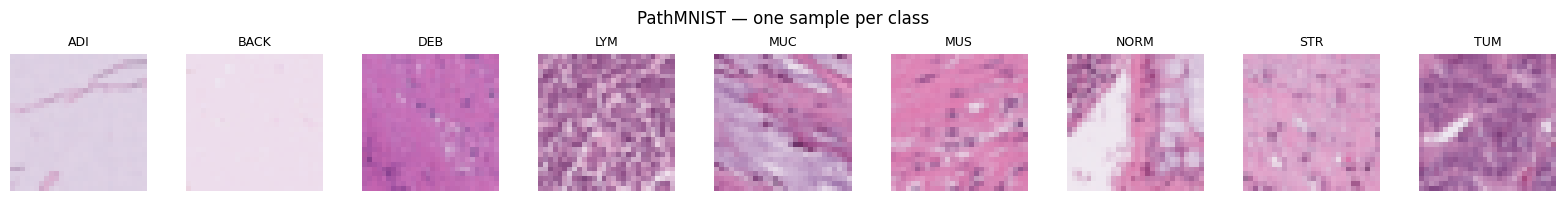

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from medmnist import PathMNIST
import time, warnings
warnings.filterwarnings('ignore')

train_ds = PathMNIST(split='train', download=True, size=28)
test_ds  = PathMNIST(split='test',  download=True, size=28)

X_train = train_ds.imgs
y_train = train_ds.labels.ravel()
X_test  = test_ds.imgs
y_test  = test_ds.labels.ravel()

class_names = ['ADI','BACK','DEB','LYM','MUC','MUS','NORM','STR','TUM']

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Classes: {len(np.unique(y_train))} — {class_names}")
print(f"Train dist: {np.bincount(y_train)}")

flat = X_train.reshape(-1, 3).astype(float)
C = np.corrcoef(flat.T)
print(f"\nGlobal channel correlations:")
print(f"  ρ(R,G) = {C[0,1]:.3f}")
print(f"  ρ(G,B) = {C[1,2]:.3f}")
print(f"  ρ(R,B) = {C[0,2]:.3f}")

# Show one sample per class
fig, axes = plt.subplots(1, 9, figsize=(16, 2))
for cls in range(9):
    idx = np.where(y_train == cls)[0][0]
    axes[cls].imshow(X_train[idx])
    axes[cls].set_title(class_names[cls], fontsize=9)
    axes[cls].axis('off')
plt.suptitle('PathMNIST — one sample per class', fontsize=12)
plt.tight_layout()
plt.show()

In [11]:
# ==================================================================
# Encoding functions + multi-basis measurement
# ==================================================================

def _theta(rgb):
    return rgb.astype(np.float64) / 255.0 * (np.pi / 2)

def _amps_sep(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([cR*cG*cB, sR*cG*cB, cR*sG*cB, sR*sG*cB,
                            cR*cG*sB, sR*cG*sB, cR*sG*sB, sR*sG*sB])

def _amps_c3e(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([ cR*cG*cB, -sR*sG*cB, -cR*sG*sB, -sR*cG*sB,
                             cR*cG*sB, -sR*sG*sB,  cR*sG*cB,  sR*cG*cB])

def _amps_ghz(rgb):
    t = _theta(rgb); c, s = np.cos(t), np.sin(t)
    cR,sR,cG,sG,cB,sB = c[:,0],s[:,0],c[:,1],s[:,1],c[:,2],s[:,2]
    return np.column_stack([
        cR*cG*cB-sR*sG*sB, sR*cG*cB+cR*sG*sB, cR*sG*cB+sR*cG*sB, sR*sG*cB-cR*cG*sB,
        cR*cG*sB+sR*sG*cB, sR*cG*sB-cR*sG*cB, cR*sG*sB-sR*cG*cB, sR*sG*sB+cR*cG*cB
    ]) / np.sqrt(2)

def _amps_cse(rgb, rho_rg, rho_gb):
    t = _theta(rgb)
    cR,sR = np.cos(t[:,0]),np.sin(t[:,0])
    cG,sG = np.cos(t[:,1]),np.sin(t[:,1])
    cB,sB = np.cos(t[:,2]),np.sin(t[:,2])
    a_rg, a_gb = rho_rg*np.pi/2, rho_gb*np.pi/2
    cGe,sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
    cBe,sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
    return np.column_stack([cR*cG*cB,  sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                            cR*cG*sB,  sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])

def _amps_pa_cse(rgb):
    t = _theta(rgb)
    cR,sR = np.cos(t[:,0]), np.sin(t[:,0])
    cG,sG = np.cos(t[:,1]), np.sin(t[:,1])
    cB,sB = np.cos(t[:,2]), np.sin(t[:,2])
    norm = rgb.astype(np.float64) / 255.0
    a_rg = norm[:,0] * norm[:,1] * np.pi / 2
    a_gb = norm[:,1] * norm[:,2] * np.pi / 2
    cGe,sGe = np.cos(t[:,1]+a_rg), np.sin(t[:,1]+a_rg)
    cBe,sBe = np.cos(t[:,2]+a_gb), np.sin(t[:,2]+a_gb)
    return np.column_stack([cR*cG*cB, sR*cGe*cB, cR*sG*cBe, sR*sGe*cBe,
                            cR*cG*sB, sR*cGe*sB, cR*sG*sBe, sR*sGe*sBe])

def apply_ry(state, theta, q):
    c = np.cos(theta/2); s = np.sin(theta/2)
    new = state.copy(); stride = 1 << q
    for a in range(8):
        if a & stride == 0:
            b = a + stride
            new[:, a] = c * state[:, a] - s * state[:, b]
            new[:, b] = s * state[:, a] + c * state[:, b]
    return new

def apply_crz(state, alpha, ctrl, tgt):
    new = state.copy(); cs, ts = 1 << ctrl, 1 << tgt
    p_neg, p_pos = np.exp(-1j * alpha / 2), np.exp(1j * alpha / 2)
    for idx in range(8):
        if idx & cs:
            new[:, idx] = (p_pos if idx & ts else p_neg) * state[:, idx]
    return new

def init_state(N):
    s = np.zeros((N, 8), dtype=complex); s[:, 0] = 1.0; return s

def _amps_cp_2L(rgb):
    t = _theta(rgb); N = len(t); s = init_state(N)
    for layer, perm in enumerate([(0,1,2), (2,0,1)]):
        s = apply_ry(s, t[:,perm[0]], 0)
        s = apply_ry(s, t[:,perm[1]], 1)
        s = apply_ry(s, t[:,perm[2]], 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[1]], 0, 1)
        s = apply_crz(s, t[:,perm[1]]*t[:,perm[2]], 1, 2)
        s = apply_crz(s, t[:,perm[0]]*t[:,perm[2]], 0, 2)
    return s

_H = np.array([[1,1],[1,-1]], dtype=complex) / np.sqrt(2)
_HSd = np.array([[1,-1j],[1,1j]], dtype=complex) / np.sqrt(2)
def _kron_n(M, n):
    R = M
    for _ in range(n-1): R = np.kron(R, M)
    return R
_V = {3: [np.eye(8,dtype=complex), _kron_n(_H,3), _kron_n(_HSd,3)]}

def multi_basis(amps, nq=3):
    return np.hstack([np.abs(amps @ V.T)**2 for V in _V[nq]])

In [12]:
# ==================================================================
# Feature extraction (FULL features) + Classification
# Memory-safe: extract ONE scheme → train → delete → next scheme.
# Peak ~7 GB per multi-basis scheme (90K × 18816 × 4B = 6.7 GB).
# ==================================================================
import torch, torch.nn as nn, gc
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import balanced_accuracy_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize
from sklearn.kernel_approximation import RBFSampler
from scipy.stats import ttest_rel

N_tr, N_te = len(X_train), len(X_test)
n_classes = len(class_names)
device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")
N_SEEDS = 5

# --- Batched extraction (avoids intermediate OOM) ---
def _ext_batched(X, fn, nq, mb, batch_size=10000):
    """Extract full features in image-batches, return complete array."""
    N = len(X)
    # Compute output dim from first batch
    sample = X[:1]
    a = fn(sample.reshape(-1, 3))
    f = multi_basis(a, nq) if mb else np.abs(a)**2
    d = f.reshape(1, -1).shape[1]
    del a, f

    out = np.empty((N, d), dtype=np.float32)
    for start in range(0, N, batch_size):
        end = min(start + batch_size, N)
        a = fn(X[start:end].reshape(-1, 3))
        f = multi_basis(a, nq) if mb else np.abs(a)**2
        out[start:end] = f.reshape(end - start, -1).astype(np.float32)
        del a, f
    return out

def _ext_cse_batched(X, mb):
    """CSE per-image extraction, full features."""
    N = len(X); d = 784 * (24 if mb else 8)
    out = np.empty((N, d), dtype=np.float32)
    for i in range(N):
        px = X[i].reshape(-1, 3).astype(float)
        c = np.corrcoef(px.T)
        rg = np.clip(abs(c[0, 1]), 0.01, 0.99)
        gb = np.clip(abs(c[1, 2]), 0.01, 0.99)
        a = _amps_cse(px, rg, gb)
        out[i] = (multi_basis(a, 3) if mb else a**2).ravel()
    return out

# --- PyTorch GPU MLP ---
def train_gpu(Xtr, ytr, Xte, yte, seed, hidden=256, epochs=150):
    torch.manual_seed(seed)
    d = Xtr.shape[1]; nc = len(np.unique(ytr))
    mu, std = Xtr.mean(0), Xtr.std(0) + 1e-8
    Xtr_n, Xte_n = (Xtr - mu) / std, (Xte - mu) / std
    loader = DataLoader(TensorDataset(torch.tensor(Xtr_n, dtype=torch.float32),
                                       torch.tensor(ytr, dtype=torch.long)),
                        batch_size=512, shuffle=True)
    model = nn.Sequential(
        nn.Linear(d, hidden), nn.ReLU(), nn.BatchNorm1d(hidden), nn.Dropout(0.3),
        nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(hidden//2, nc)).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    for ep in range(epochs):
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss_fn(model(xb), yb).backward(); opt.step()
        sched.step()
    model.eval()
    with torch.no_grad():
        Xt = torch.tensor(Xte_n, dtype=torch.float32).to(device)
        logits = model(Xt)
        pred = logits.argmax(1).cpu().numpy()
        probs = torch.softmax(logits, 1).cpu().numpy()
    del model, loader, Xt, logits
    torch.mps.empty_cache() if hasattr(torch.mps, 'empty_cache') else None
    return pred, probs

# --- Scheme configs ---
configs = [
    ('Raw RGB',          None,          3, False),
    ('Sep (Z)',          _amps_sep,     3, False),
    ('Sep (Z+X+Y)',      _amps_sep,    3, True),
    ('C3E (Z+X+Y)',      _amps_c3e,    3, True),
    ('GHZ-CE (Z+X+Y)',   _amps_ghz,   3, True),
    ('CSE (Z+X+Y)',      'cse',        3, True),
    ('PA-CSE (Z+X+Y)',   _amps_pa_cse, 3, True),
    ('CP-2L (Z+X+Y)',    _amps_cp_2L,  3, True),
    ('RBF-24 (classical)', 'rbf',      3, True),
]

y_te_bin = label_binarize(y_test, classes=np.arange(n_classes))

print(f"\nSOTA ref: ResNet-18(28) ACC≈0.909  AUC≈0.989")
print(f"Full features → PyTorch GPU MLP ({N_SEEDS} seeds)")
print()
print(f"{'Scheme':25s}  {'ACC':>8s} {'±':>6s}  {'BA':>8s} {'±':>6s}  {'AUC':>8s} {'±':>6s}  {'dim':>6s}")
print("=" * 95)

summary = {}
all_accs = {}
t_total = time.time()

for name, fn, nq, mb in configs:
    t0 = time.time()

    # --- Extract features ---
    if fn is None:  # Raw RGB
        Ftr = X_train.reshape(N_tr, -1).astype(np.float32) / 255.0
        Fte = X_test.reshape(N_te, -1).astype(np.float32) / 255.0
    elif fn == 'rbf':  # Classical RBF baseline
        rbf24 = RBFSampler(n_components=24, gamma=1.0, random_state=42)
        px_tr = X_train.reshape(-1, 3).astype(np.float32) / 255.0
        rbf24.fit(px_tr)
        Ftr = rbf24.transform(px_tr).reshape(N_tr, -1).astype(np.float32)
        Fte = rbf24.transform(X_test.reshape(-1, 3).astype(np.float32) / 255.0).reshape(N_te, -1).astype(np.float32)
        del px_tr, rbf24
    elif fn == 'cse':
        Ftr = _ext_cse_batched(X_train, mb)
        Fte = _ext_cse_batched(X_test, mb)
    else:
        Ftr = _ext_batched(X_train, fn, nq, mb)
        Fte = _ext_batched(X_test, fn, nq, mb)

    ext_time = time.time() - t0

    # --- Train & evaluate ---
    accs, bas, aucs = [], [], []
    for seed in range(N_SEEDS):
        pred, probs = train_gpu(Ftr, y_train, Fte, y_test, seed=seed)
        accs.append(accuracy_score(y_test, pred))
        bas.append(balanced_accuracy_score(y_test, pred))
        aucs.append(roc_auc_score(y_te_bin, probs, multi_class='ovr', average='macro'))

    d = Ftr.shape[1]
    summary[name] = dict(acc=np.mean(accs), acc_s=np.std(accs),
                         ba=np.mean(bas), ba_s=np.std(bas),
                         auc=np.mean(aucs), auc_s=np.std(aucs), d=d)
    all_accs[name] = accs
    tag = " ← CLS" if "classical" in name or "Raw" in name else ""
    print(f"{name:25s}  {np.mean(accs):.4f} ±{np.std(accs):.4f}  "
          f"{np.mean(bas):.4f} ±{np.std(bas):.4f}  "
          f"{np.mean(aucs):.4f} ±{np.std(aucs):.4f}  {d:>6d}  "
          f"(ext:{ext_time:.0f}s total:{time.time()-t0:.0f}s){tag}")

    # --- Free memory before next scheme ---
    del Ftr, Fte; gc.collect()

print(f"\nTotal: {time.time()-t_total:.0f}s")

# Rankings
print("\nRANKING BY ACC:")
for i, (n, v) in enumerate(sorted(summary.items(), key=lambda x: -x[1]['acc'])):
    tag = " ← CLASSICAL" if "classical" in n or "Raw" in n else ""
    print(f"  {i+1}. {n:25s}  ACC={v['acc']:.4f}  BA={v['ba']:.4f}  AUC={v['auc']:.4f}  d={v['d']}{tag}")

# Fair comparison: same-dim quantum vs classical (18816)
print("\nFAIR COMPARISON (18816 features — quantum Z+X+Y vs RBF-24):")
fair = {k: v for k, v in summary.items() if v['d'] == 18816}
for n, v in sorted(fair.items(), key=lambda x: -x[1]['acc']):
    tag = " ← CLASSICAL" if "classical" in n else ""
    print(f"  {n:25s}  ACC={v['acc']:.4f} ± {v['acc_s']:.4f}{tag}")

# Paired t-tests vs Sep(Z+X+Y) baseline
print("\nPAIRED T-TESTS vs Sep(Z+X+Y):")
ref = 'Sep (Z+X+Y)'
if ref in all_accs:
    for name in sorted(all_accs.keys()):
        if name == ref: continue
        diff = np.array(all_accs[name]) - np.array(all_accs[ref])
        t_stat, p_val = ttest_rel(all_accs[name], all_accs[ref])
        print(f"  {name:25s}  diff={np.mean(diff):+.4f}  p={p_val:.4f}  {'*' if p_val < 0.05 else ''}")

Device: mps

SOTA ref: ResNet-18(28) ACC≈0.909  AUC≈0.989
Full features → PyTorch GPU MLP (5 seeds)

Scheme                          ACC      ±        BA      ±       AUC      ±     dim
Raw RGB                    0.6754 ±0.0040  0.6109 ±0.0046  0.9219 ±0.0039    2352  (ext:1s total:420s) ← CLS
Sep (Z)                    0.6791 ±0.0061  0.6134 ±0.0079  0.9247 ±0.0065    6272  (ext:5s total:633s)
Sep (Z+X+Y)                0.7033 ±0.0068  0.6623 ±0.0060  0.9404 ±0.0012   18816  (ext:28s total:2511s)
C3E (Z+X+Y)                0.7011 ±0.0022  0.6583 ±0.0017  0.9411 ±0.0005   18816  (ext:22s total:2318s)
GHZ-CE (Z+X+Y)             0.7035 ±0.0060  0.6368 ±0.0100  0.9287 ±0.0073   18816  (ext:20s total:2453s)
CSE (Z+X+Y)                0.1717 ±0.0000  0.1111 ±0.0000  0.5000 ±0.0000   18816  (ext:17s total:2287s)
PA-CSE (Z+X+Y)             0.7196 ±0.0023  0.6788 ±0.0019  0.9403 ±0.0013   18816  (ext:20s total:1747s)
CP-2L (Z+X+Y)              0.7226 ±0.0032  0.6660 ±0.0094  0.9347 ±0.0041   1

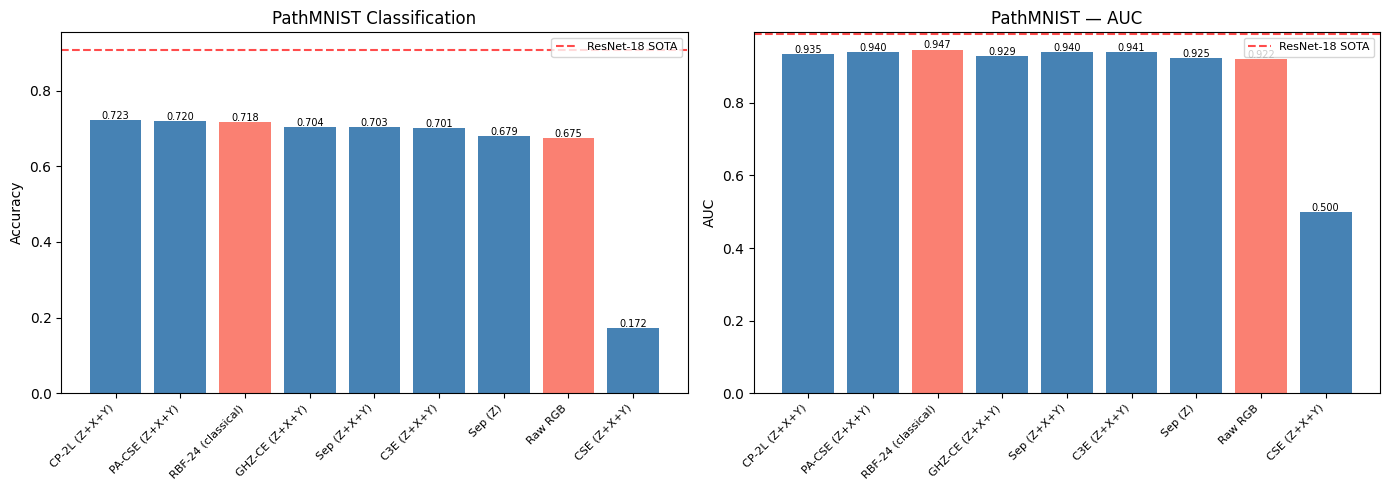

In [13]:
# ==================================================================
# Visualization
# ==================================================================
scheme_order = [n for n, _ in sorted(summary.items(), key=lambda x: -x[1]['acc'])]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['salmon' if 'classical' in s or 'Raw' in s else 'steelblue' for s in scheme_order]

accs = [summary[s]['acc'] for s in scheme_order]
bars = axes[0].bar(range(len(scheme_order)), accs, color=colors)
axes[0].set_xticks(range(len(scheme_order)))
axes[0].set_xticklabels(scheme_order, rotation=45, ha='right', fontsize=8)
axes[0].set_ylabel('Accuracy')
axes[0].set_title('PathMNIST Classification')
axes[0].axhline(y=0.909, color='red', linestyle='--', alpha=0.7, label='ResNet-18 SOTA')
axes[0].legend(fontsize=8)
for bar, v in zip(bars, accs):
    axes[0].text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=7)

aucs_v = [summary[s]['auc'] for s in scheme_order]
bars2 = axes[1].bar(range(len(scheme_order)), aucs_v, color=colors)
axes[1].set_xticks(range(len(scheme_order)))
axes[1].set_xticklabels(scheme_order, rotation=45, ha='right', fontsize=8)
axes[1].set_ylabel('AUC')
axes[1].set_title('PathMNIST — AUC')
axes[1].axhline(y=0.989, color='red', linestyle='--', alpha=0.7, label='ResNet-18 SOTA')
axes[1].legend(fontsize=8)
for bar, v in zip(bars2, aucs_v):
    axes[1].text(bar.get_x()+bar.get_width()/2, v+0.003, f'{v:.3f}', ha='center', fontsize=7)

plt.tight_layout()
plt.show()